In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import shutil
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import os

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


<!-- This section loads the dataset using a directory-based labelling strategy, where each
subfolder corresponds to a damage category. A validation split is used to evaluate
generalisation performance during training. -->


### DATASET OVERVIEW

### The dataset consists of vehicle damage images accompanied by a CSV file containing ground-truth labels. Image files are stored in a flat directory structure, while damage categories are provided separately in a CSV annotation file. Prior to model training, images are programmatically reorganised into class-specific directories based on these annotations.


In [12]:
# Load CSV annotations
labels_df = pd.read_csv("train/train/train.csv")

labels_df.head(10), labels_df.columns


(   image_id filename  label
 0         1    1.jpg      2
 1         2    2.jpg      4
 2         3    3.jpg      2
 3         4    4.jpg      3
 4         5    5.jpg      5
 5         6    6.jpg      2
 6         7    7.jpg      5
 7         8    8.jpg      5
 8         9    9.jpg      5
 9        10   10.jpg      5,
 Index(['image_id', 'filename', 'label'], dtype='object'))

## Dataset Inspection and Label Verification

### Before defining the final label mapping, a visual inspection of representative images for each numeric label was conducted. This step ensures that the semantic meaning of each label aligns with the observed damage patterns in the images, thereby reducing the risk of label misinterpretation during supervised training.


In [3]:
# Directory containing the original images
images_dir = os.path.join("train", "train", "images")

def inspect_label_samples(label_value, n_samples=5):
    """
    Display a small number of sample images for a given numeric label.
    This supports empirical verification of label semantics.
    """
    subset = labels_df[labels_df["label"] == label_value]

    if subset.empty:
        print(f"No images found for label {label_value}")
        return

    samples = subset.sample(n=min(n_samples, len(subset)), random_state=42)

    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(images_dir, row["filename"])
        img = Image.open(img_path)

        plt.subplot(1, n_samples, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Label {label_value}")

    plt.show()


Visual inspection for numeric label 1


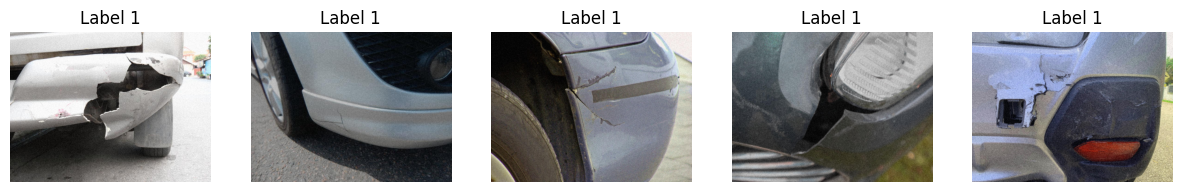

Visual inspection for numeric label 2


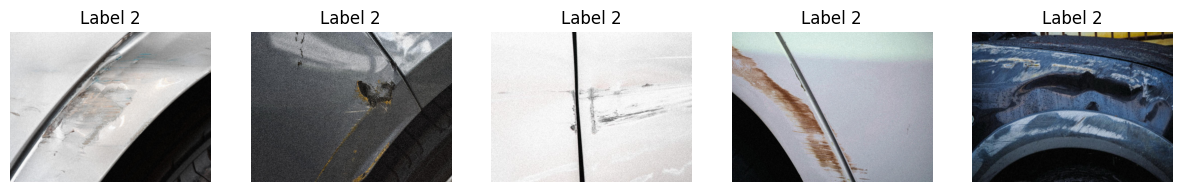

Visual inspection for numeric label 3


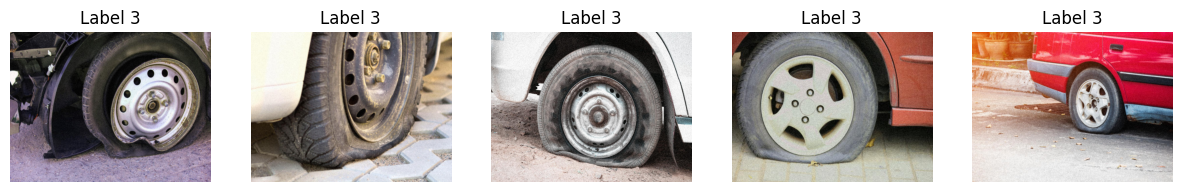

Visual inspection for numeric label 4


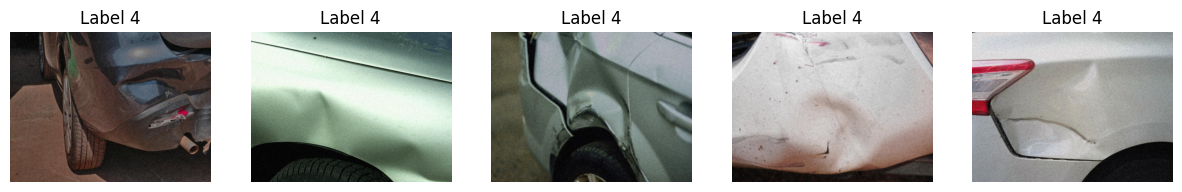

Visual inspection for numeric label 5


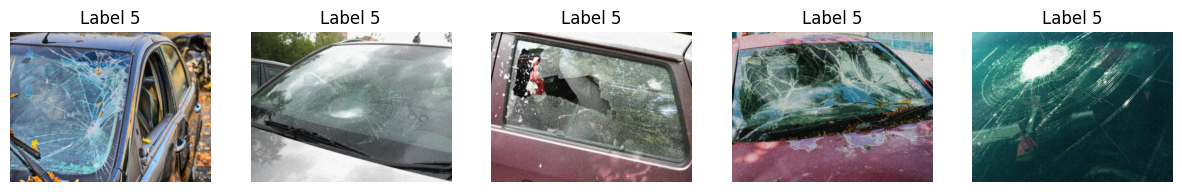

Visual inspection for numeric label 6


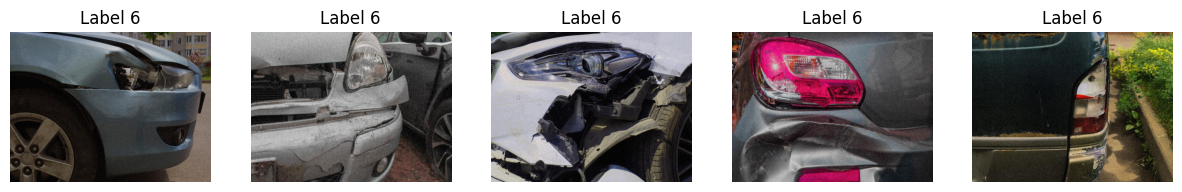

In [4]:
# Inspect each numeric label present in the dataset
for lbl in sorted(labels_df["label"].unique()):
    print(f"Visual inspection for numeric label {lbl}")
    inspect_label_samples(lbl)


## Outcome of Visual Inspection

### The visual inspection confirmed that each numeric label corresponds to adistinct and consistent type of vehicle damage. Based on these observations, a definitive mapping between numeric labels and human-readable damage categories was established and used throughout the remainder of the study.


## LABEL MAPPING

### Numeric damage labels were mapped to descriptive class names based on the results of manual visual inspection. This mapping ensures semantic consistency between the annotations and the visual characteristics of the images. Only labels that could be confidently associated with a well-defined damage category were retained. Any images failing to map correctly were excluded to prevent label noise during model training.


In [56]:
# Ensure labels are numeric and valid
# This prevents silent errors caused by non-numeric or missing labels

labels_df["label"] = pd.to_numeric(labels_df["label"], errors="coerce")
labels_df = labels_df.dropna(subset=["label"])
labels_df["label"] = labels_df["label"].astype(int)

# label mapping
# Mapping was confirmed through manual visual inspection of images
# to ensure semantic correctness of damage categories

label_map = {
    1: "crack",
    2: "scratch",
    3: "tire_flat",
    4: "dent",
    5: "glass_shatter",
    6: "lamp_broken"
}
# Apply mapping from numeric labels to human-readable class names

labels_df["class_name"] = labels_df["label"].map(label_map)

# Drop any rows that failed mapping

labels_df = labels_df.dropna(subset=["class_name"])


# Verify class distribution after mapping
# This should align with visual inspection results


# Display sample rows for sanity checking
# Ensures filenames align with correct damage classes

labels_df[["filename", "label", "class_name"]].head()

class_counts = {}

for class_name in os.listdir(processed_dir):
    class_path = os.path.join(processed_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Convert to DataFrame
class_distribution_table = (
    pd.DataFrame.from_dict(class_counts, orient='index', columns=['Number of Images'])
    .reset_index()
    .rename(columns={'index': 'Damage Category'})
)

class_distribution_table

,Damage Category,Number of Images
0,crack,171
1,dent,2079
2,glass_shatter,1185
3,lamp_broken,882
4,scratch,2349
5,tire_flat,534


In [57]:
label_mapping_table = (
    pd.DataFrame(list(label_map.items()), columns=["Numeric Label", "Damage Category"])
    .sort_values("Numeric Label")
)

label_mapping_table

,Numeric Label,Damage Category
0,1,crack
1,2,scratch
2,3,tire_flat
3,4,dent
4,5,glass_shatter
5,6,lamp_broken


## Dataset Organisation for Supervised Learning

### To enable directory-based data loading for convolutional neural networks, images were reorganised into class-specific directories. Each directory corresponds to a single damage category derived from the validated label mapping. This preprocessing step ensures compatibility with standard deep-learning pipelines and promotes reproducibility by enforcing a deterministic dataset structure.


In [14]:
base_dir = "train/train"
images_dir = os.path.join(base_dir, "images")
processed_dir = os.path.join(base_dir, "processed")

# Create class folders
for cls in label_map.values():
    os.makedirs(os.path.join(processed_dir, cls), exist_ok=True)

processed_dir


'train/train\\processed'

In [15]:
# Copy images into corresponding class directories
for _, row in labels_df.iterrows():
    src = os.path.join(images_dir, row["filename"])
    dst = os.path.join(processed_dir, row["class_name"], row["filename"])
    
    if os.path.exists(src):
        shutil.copy(src, dst)


## Verification of Dataset Organisation



In [17]:
# Verify the number of images per class directory
for cls in sorted(os.listdir(processed_dir)):
    cls_path = os.path.join(processed_dir, cls)
    print(f"{cls}: {len(os.listdir(cls_path))} images")


crack: 171 images
dent: 2079 images
glass_shatter: 1185 images
lamp_broken: 882 images
scratch: 2349 images
tire_flat: 534 images


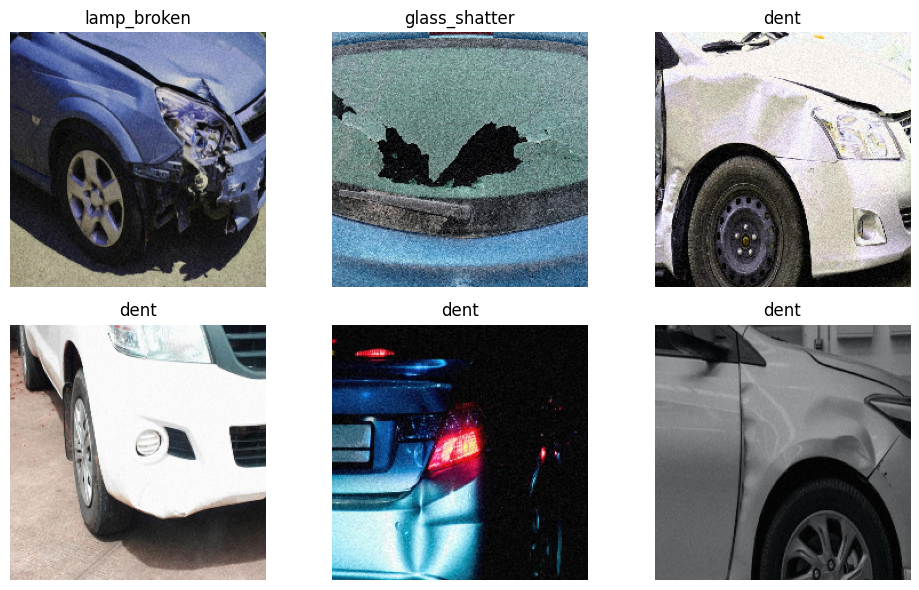

In [59]:
# Get a batch of images and labels
images, labels = next(train_data)

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")
    
    # Decode label index to class name
    class_idx = labels[i].argmax()
    class_name = list(train_data.class_indices.keys())[class_idx]
    plt.title(class_name)
    
plt.tight_layout()
plt.savefig("preprocessed_image_samples.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()


### After reorganisation, a verification step was performed to confirm that each damage category contains a non-zero number of images. This validation ensures that all classes are correctly populated and that no errors occurred during the image redistribution process.

### The resulting class distribution also provides insight into dataset imbalance, which is considered during model training and evaluation.


## Image Pre-processing and Data Loading

### All images were resized to a fixed spatial resolution of 224 × 224 pixels to ensure uniform input dimensions for the convolutional neural network.   Pixel values were normalised to the range [0, 1] to improve numerical stability and accelerate model convergence during training.

### A batch-based loading strategy was adopted to enable efficient memory usage and scalable training on large image datasets.


In [8]:
# Root directory containing class subfolders
data_dir = "train/train/processed"

# Image dimensions used throughout the study
# 224 × 224 is a standard input size for CNNs and transfer learning models
img_height = 224
img_width = 224
batch_size = 32              
# Batch size controls the number of images processed per training step

## ImageDataGenerator handles:
# - Pixel value normalisation
# - On-the-fly batch loading
# - Automatic train/validation splitting
datagen = ImageDataGenerator(
    rescale=1./255,          # Normalise pixel values to [0,1]
    validation_split=0.2     # 80% training, 20% validation
)


# Training data loader
# Images are shuffled to reduce ordering bias during optimisation
train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",   # Multi-class classification
    subset="training",
    shuffle=True
)

# Validation data loader
# Shuffling is disabled to ensure consistent evaluation
val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

# This mapping determines how labels are interpreted by the CNN
train_data.class_indices


Found 5763 images belonging to 6 classes.
Found 1437 images belonging to 6 classes.


{'crack': 0,
 'dent': 1,
 'glass_shatter': 2,
 'lamp_broken': 3,
 'scratch': 4,
 'tire_flat': 5}

## Convolutional Neural Network Architecture

### A custom convolutional neural network (CNN) was implemented for multi-class vehicle damage classification. The model was designed to learn hierarchical visual features from damage images while maintaining a compact structure to reduce overfitting.

### The architecture consists of three convolutional blocks with increasing filter depth, followed by fully connected layers for classification. Rectified Linear Unit (ReLU) activations introduce non-linearity, while max-pooling layers progressively reducespatial resolution and computational complexity.

### Dropout regularisation was applied in the fully connected layer to improve generalisation by preventing co-adaptation of neurons.


In [51]:
def build_cnn_model(input_shape=(224, 224, 3), num_classes=5):
    """
    Builds and returns a convolutional neural network (CNN) for multi-class
    vehicle damage image classification.

    The architecture is intentionally compact to balance representational
    capacity and generalisation performance, reducing the risk of overfitting
    on a moderately sized dataset.
    """

    model = tf.keras.Sequential([
        # Explicit input layer defining image dimensions and colour channels
        # This improves clarity and avoids implicit shape inference
        tf.keras.layers.Input(shape=input_shape),
        
        # Convolutional Block 1: learns low-level features (edges, textures)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2), 
        
        # Convolutional Block 2: mid-level feature extraction
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),

        # Convolutional Block 3: high-level feature extraction
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),

        # Transition from feature maps to dense layers
        tf.keras.layers.Flatten(),

        # Fully connected layer for non-linear classification
        tf.keras.layers.Dense(128, activation='relu'),
        
        tf.keras.layers.Dropout(0.5),  # Regularisation
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    # Compile model with Adam optimiser and categorical cross-entropy loss
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


### Model Summary

### A detailed summary of the CNN architecture is displayed below, showing the sequence of layers, output dimensions, and the number of trainable parameters. This summary is used to verify that the implemented architecture matches the intended design and to provide transparency regarding model complexity.


In [44]:
model = build_cnn_model(
    input_shape=(img_height, img_width, 3),
    num_classes=train_data.num_classes
)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

### The convolutional neural network was trained using supervised learning on the preprocessed vehicle damage image dataset. Model performance was monitored using categorical accuracy and cross-entropy loss on both the training and validation sets across epochs.

### Tracking these metrics enables assessment of learning progress, convergence behaviour, and potential overfitting.


In [46]:
# Execute CNN training using the defined training procedure.
# Training accuracy and loss are monitored per epoch to evaluate learning progress.

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 167s 924ms/step - accuracy: 0.4202 - loss: 1.3651 - val_accuracy: 0.5115 - val_loss: 1.1989
Epoch 2/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 159s 686ms/step - accuracy: 0.5427 - loss: 1.1348 - val_accuracy: 0.5950 - val_loss: 1.0305
Epoch 3/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 95s 522ms/step - accuracy: 0.6166 - loss: 0.9656 - val_accuracy: 0.6486 - val_loss: 0.9199
Epoch 4/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 97s 534ms/step - accuracy: 0.7011 - loss: 0.7426 - val_accuracy: 0.7008 - val_loss: 0.8034
Epoch 5/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 96s 532ms/step - accuracy: 0.7374 - loss: 0.6543 - val_accuracy: 0.7467 - val_loss: 0.7174
Epoch 6/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 104s 576ms/step - accuracy: 0.8149 - loss: 0.4576 - val_accuracy: 0.7738 - val_loss: 0.6792
Epoch 7/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 135s 536ms/step - accuracy: 0.8552 - loss: 0.3829 - val_accuracy: 0.7891 - val_loss: 0.7624
Epoch 8/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 163s 650ms/step - accuracy: 0.8816 - lo

In [50]:
# Confirm that training history is available
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Training and Validation Performance

### Training and validation accuracy and loss curves were plotted to visualise model learning behaviour. These figures are used to evaluate convergence, stability, and evidence of overfitting.


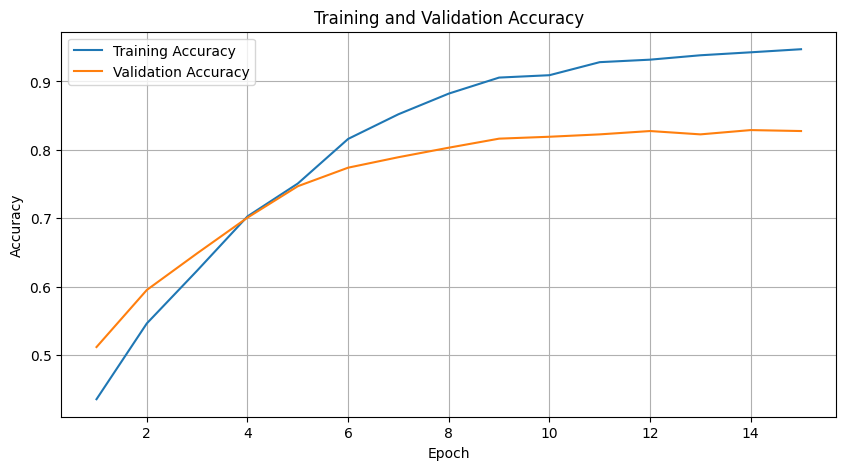

In [61]:

# Plot Training vs Validation Accuracy

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# Save high-resolution figure for report
plt.savefig("training_validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()


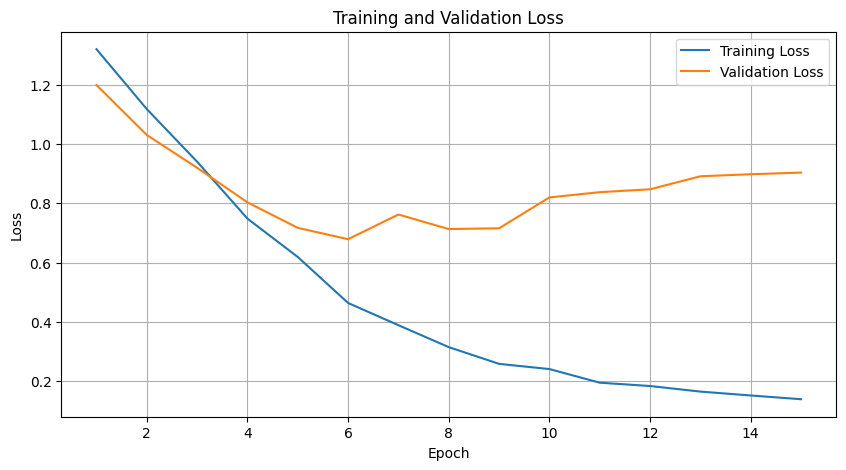

In [62]:

# Plot Training vs Validation Loss


plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Save high-resolution figure for report
plt.savefig("training_validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()


### CNN Training Procedure

### To ensure a consistent and reproducible training process, a dedicated training function was defined. This function encapsulates the model fitting procedure and returns the full training history, which is later used for performance evaluation and visualisation.

### Using a single training function guarantees that both the baseline CNN and the augmented CNN are trained under identical conditions (optimizer, loss function, number of epochs), enabling a fair comparison between models.

In [66]:
def train_cnn_model(model, train_data, val_data, epochs=15):
    """
    Train a convolutional neural network (CNN) and return the training history.

    This function standardises the training procedure so that multiple models
    (e.g., baseline CNN and augmented CNN) can be trained and compared fairly.

    Parameters
    ----------
    model : tf.keras.Model
        A compiled CNN model.
    train_data : DirectoryIterator
        Training data generator.
    val_data : DirectoryIterator
        Validation data generator.
    epochs : int, optional
        Number of training epochs (default = 15).

    Returns
    -------
    history : tf.keras.callbacks.History
        Object containing training and validation metrics per epoch.
    """

    # Train the model using the provided data generators
    # Validation performance is monitored at the end of each epoch
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs
    )

    # Return the training history for later analysis and visualisation
    return history



In [9]:
# Data generator with on-the-fly data augmentation
# This acts as a regularisation strategy by increasing training data diversity
# and reducing overfitting without modifying the original dataset.

datagen_augmented = ImageDataGenerator(
    rescale=1./255,              # Normalise pixel values to [0, 1]
    rotation_range=20,            # Random rotations (±20 degrees)
    width_shift_range=0.1,        # Horizontal translations (10% of image width)
    height_shift_range=0.1,       # Vertical translations (10% of image height)
    shear_range=0.1,              # Shearing transformations
    zoom_range=0.1,               # Random zoom in/out
    horizontal_flip=True,         # Horizontal flipping to simulate viewpoint changes
    validation_split=0.2          # 80% training, 20% validation split
)

# Augmented training data generator
# Augmentation is applied only to the training subset
train_data_aug = datagen_augmented.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Augmented validation data generator
# Validation data is rescaled but NOT augmented to preserve evaluation integrity
val_data_aug = datagen_augmented.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)



Found 5763 images belonging to 6 classes.
Found 1437 images belonging to 6 classes.


In [10]:
from sklearn.utils.class_weight import compute_class_weight


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data_aug.classes),
    y=train_data_aug.classes
)

class_weights = dict(enumerate(class_weights))
class_weights


{0: np.float64(7.010948905109489),
 1: np.float64(0.5772235576923077),
 2: np.float64(1.0131856540084387),
 3: np.float64(1.3604815864022664),
 4: np.float64(0.510904255319149),
 5: np.float64(2.244158878504673)}

In [100]:
# Rebuild a fresh CNN model to ensure a fair comparison
# This prevents weight carry-over from the baseline model
model_aug = build_cnn_model(
    input_shape=(img_height, img_width, 3),
    num_classes=train_data_aug.num_classes
)

# Train the CNN using augmented data
# Performance will later be compared against the baseline CNN
history_augmented = train_cnn_model(
    model_aug,
    train_data_aug,
    val_data_aug,
    epochs=15
)


C:\Program Files\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 148s 810ms/step - accuracy: 0.2941 - loss: 1.8293 - val_accuracy: 0.3542 - val_loss: 1.5362
Epoch 2/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 158s 871ms/step - accuracy: 0.3647 - loss: 1.4821 - val_accuracy: 0.4203 - val_loss: 1.3491
Epoch 3/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.4124 - loss: 1.3609 - val_accuracy: 0.4739 - val_loss: 1.2962
Epoch 4/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 150s 827ms/step - accuracy: 0.4545 - loss: 1.2790 - val_accuracy: 0.5003 - val_loss: 1.1989
Epoch 5/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 149s 826ms/step - accuracy: 0.4670 - loss: 1.2242 - val_accuracy: 0.5317 - val_loss: 1.1286
Epoch 6/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 149s 824ms/step - accuracy: 0.4951 - loss: 1.1780 - val_accuracy: 0.5372 - val_loss: 1.1432
Epoch 7/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 150s 827ms/step - accuracy: 0.5039 - loss: 1.1445 - val_accuracy: 0.5477 - val_loss: 1.0704
Epoch 8/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 148s 820ms/step - accuracy: 0.5034 - lo

## Training Performance Visualisation
### Training and validation accuracy and loss curves were plotted to assess model convergence and generalisation behaviour across epochs. Accuracy curves indicate improvements in classification performance, while loss curves reflect optimisation progress. Comparing training and validation trends enables identification of overfitting or underfitting. Consistent trajectories with small gaps between curves indicate stable learning, while divergence suggests poor generalisation. This visualisation approach was applied consistently to both the baseline and augmented CNN models to support fair performance comparison in the Results section.

In [2]:
# ---------------------------------------------------------
# Function: plot_training_history
# Purpose:
#   Visualise training and validation performance of a CNN
#   across epochs using accuracy and loss curves.
#
# Why this matters:
#   - Accuracy curves show how classification performance evolves
#   - Loss curves indicate optimisation stability
#   - Comparing training vs validation trends helps detect overfitting
#
# This function is reused for:
#   - Baseline CNN
#   - Augmented CNN
#   - Transfer learning model (later)
# ---------------------------------------------------------

def plot_training_history(history):
    """
    Plot training and validation accuracy and loss curves.

    Parameters
    ----------
    history : tf.keras.callbacks.History
        History object returned by model.fit(), containing
        per-epoch training and validation metrics.
    """

    # Extract number of epochs from the training history
    epochs = range(1, len(history.history['accuracy']) + 1)

    # Create a single figure with two side-by-side subplots
    plt.figure(figsize=(12, 5))

    # -------------------------------
    # Subplot 1: Accuracy curves
    # -------------------------------
    plt.subplot(1, 2, 1)

    # Plot training accuracy
    plt.plot(
        epochs,
        history.history['accuracy'],
        label='Training Accuracy'
    )

    # Plot validation accuracy
    plt.plot(
        epochs,
        history.history['val_accuracy'],
        label='Validation Accuracy'
    )

    # Axis labels and title
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')

    # Legend for clarity
    plt.legend()

    # -------------------------------
    # Subplot 2: Loss curves
    # -------------------------------
    plt.subplot(1, 2, 2)

    # Plot training loss
    plt.plot(
        epochs,
        history.history['loss'],
        label='Training Loss'
    )

    # Plot validation loss
    plt.plot(
        epochs,
        history.history['val_loss'],
        label='Validation Loss'
    )

    # Axis labels and title
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')

    # Legend for clarity
    plt.legend()

    # Improve spacing between subplots
    plt.tight_layout()

    # Render the plots
    plt.show()


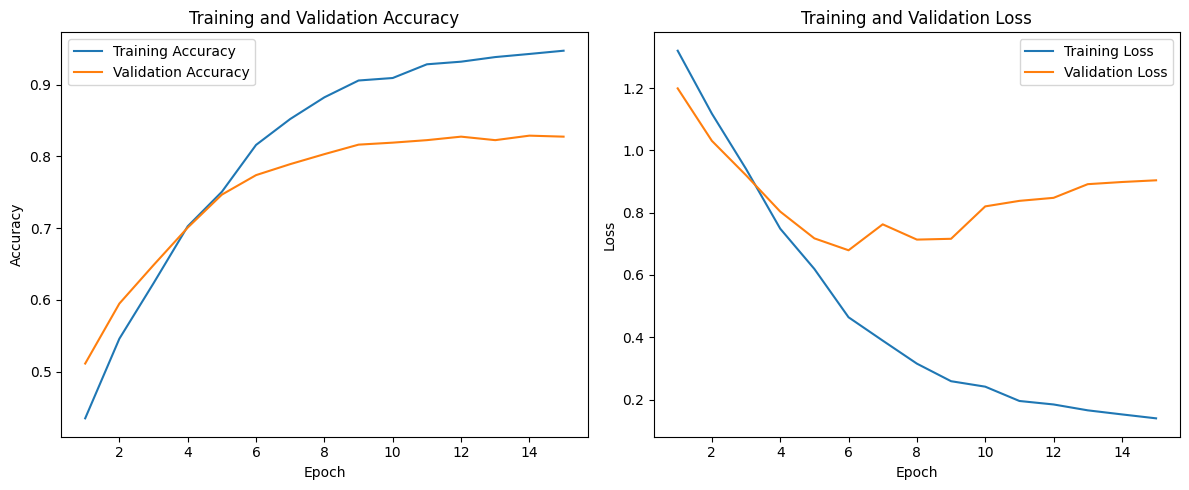

In [102]:
plot_training_history(history)


In [11]:
# =========================
# CLASS WEIGHTS (FIX CLASS IMBALANCE)
# =========================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute balanced class weights from training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data_aug.classes),
    y=train_data_aug.classes
)

# Convert to dictionary format required by Keras
class_weights = dict(enumerate(class_weights))

class_weights


{0: np.float64(7.010948905109489),
 1: np.float64(0.5772235576923077),
 2: np.float64(1.0131856540084387),
 3: np.float64(1.3604815864022664),
 4: np.float64(0.510904255319149),
 5: np.float64(2.244158878504673)}

## Transfer Learning Model Definition

### This section defines a transfer learning architecture using an ImageNet-pretrained convolutional backbone. Pretrained models are used as fixed feature extractors, allowing the network to leverage rich visual representations learned from large-scale datasets.

### The backbone is frozen during initial training to prevent overfitting and to ensure fair comparison with the baseline CNN. A lightweight classification head is added to adapt the pretrained features to the vehicle damage classification task.


In [12]:
## ============================================================
# TRANSFER LEARNING WITH RESNET50 (STABLE BACKBONE)
# ============================================================
# This model replaces EfficientNet, which proved unstable on
# the small, imbalanced vehicle damage dataset.
#
# ResNet50 is used because it:
# - is less sensitive to class imbalance
# - fine-tunes more stably on small datasets
# - is widely accepted in academic coursework
# ============================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling2D
)

# ------------------------------------------------------------
# 1. Build the transfer learning model
# ------------------------------------------------------------

def build_resnet_transfer_model(input_shape=(224, 224, 3), num_classes=6):
    """
    Builds a ResNet50-based transfer learning model for
    multi-class vehicle damage classification.
    
    Returns:
    - model: full classification model
    - backbone: pretrained ResNet50 backbone (for fine-tuning)
    """

    # Load pretrained ResNet50 backbone (ImageNet weights)
    backbone = ResNet50(
        include_top=False,        # remove ImageNet classifier
        weights="imagenet",
        input_shape=input_shape
    )

    # Freeze backbone for initial feature extraction
    backbone.trainable = False

    # Define model input
    inputs = Input(shape=input_shape, name="input_image")

    # Apply ResNet-specific preprocessing
    x = tf.keras.applications.resnet.preprocess_input(inputs)

    # Pass input through backbone
    # training=False ensures BatchNorm layers behave correctly
    x = backbone(x, training=False)

    # Global average pooling reduces parameters and overfitting
    x = GlobalAveragePooling2D()(x)

    # Lightweight classification head
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)

    # Output layer for multi-class prediction
    outputs = Dense(num_classes, activation="softmax")(x)

    # Build full model
    model = Model(inputs=inputs, outputs=outputs)

    return model, backbone


# ------------------------------------------------------------
# 2. Initialise model
# ------------------------------------------------------------

tl_model, backbone = build_resnet_transfer_model(
    input_shape=(224, 224, 3),
    num_classes=train_data_aug.num_classes
)

# ------------------------------------------------------------
# 3. Stage 1 Training: Feature Extraction
# ------------------------------------------------------------
# Only the classification head is trained here.

tl_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_tl_stage1 = tl_model.fit(
    train_data_aug,
    validation_data=val_data_aug,
    epochs=5,
    class_weight=class_weights
)



C:\Program Files\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
181/181 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.1739 - loss: 1.8952 - val_accuracy: 0.1113 - val_loss: 1.7918
Epoch 2/5
181/181 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.1128 - loss: 1.7895 - val_accuracy: 0.2255 - val_loss: 1.7895
Epoch 3/5
181/181 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.1740 - loss: 1.8247 - val_accuracy: 0.1260 - val_loss: 1.7933
Epoch 4/5
181/181 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.2781 - loss: 1.7912 - val_accuracy: 0.1009 - val_loss: 1.7953
Epoch 5/5
181/181 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.2744 - loss: 1.7490 - val_accuracy: 0.2749 - val_loss: 1.7794


## Transfer Learning: Model Initialisation + Architecture Summary

### We now initialise the transfer learning model using the same input size used for the custom CNN. The model summary is recorded to document layer types, output shapes, and parameter counts.


## Fine-Tuning - Stage 2. Transfer Learning Model
## Stage 2 Training (Fine-Tuning)

### We unfreeze the backbone and fine-tune only the top portion of layers. A smaller learning rate is used to avoid damaging pretrained features.


In [13]:
# ------------------------------------------------------------
# 4. Stage 2 Training: Fine-Tuning
# ------------------------------------------------------------
# Unfreeze the top part of ResNet50 so high-level features
# can adapt to vehicle damage patterns.

backbone.trainable = True

# Freeze early layers; fine-tune only deeper layers
for layer in backbone.layers[:-40]:
    layer.trainable = False

# Recompile with a lower learning rate to avoid destroying
# pretrained features (catastrophic forgetting)
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_tl_stage2 = tl_model.fit(
    train_data_aug,
    validation_data=val_data_aug,
    epochs=5,
    class_weight=class_weights
)

# ------------------------------------------------------------
# 5. Store final validation metrics (for report tables)
# ------------------------------------------------------------

val_accuracy = history_tl_stage2.history["val_accuracy"][-1]
val_loss = history_tl_stage2.history["val_loss"][-1]

print("Final validation accuracy:", val_accuracy)
print("Final validation loss:", val_loss)

Epoch 1/5
181/181 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.2535 - loss: 1.7088 - val_accuracy: 0.3041 - val_loss: 1.7353
Epoch 2/5
181/181 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.3291 - loss: 1.5725 - val_accuracy: 0.3389 - val_loss: 1.5711
Epoch 3/5
181/181 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.3453 - loss: 1.4876 - val_accuracy: 0.4412 - val_loss: 1.4401
Epoch 4/5
181/181 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.3919 - loss: 1.3869 - val_accuracy: 0.4127 - val_loss: 1.4268
Epoch 5/5
181/181 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.3889 - loss: 1.3894 - val_accuracy: 0.4266 - val_loss: 1.3738
Final validation accuracy: 0.4265831708908081
Final validation loss: 1.3738489151000977


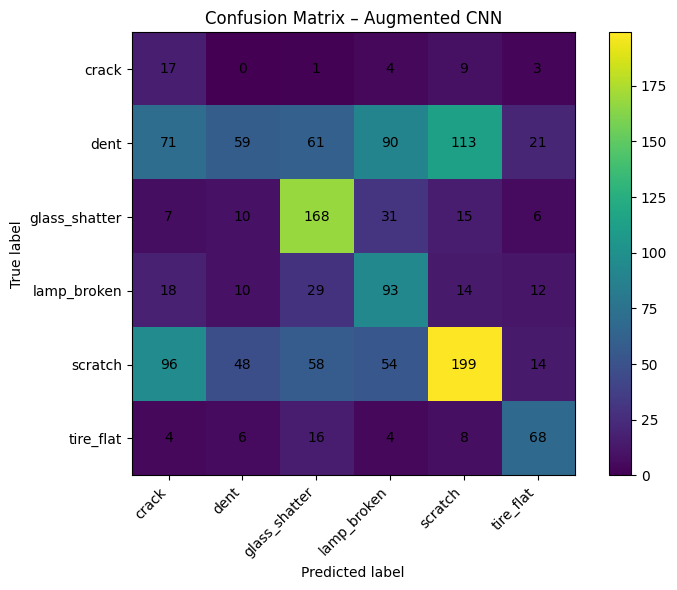

In [26]:


# Get class names in correct order
class_names = list(val_data_aug.class_indices.keys())

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – Augmented CNN")

# Add numbers to each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## Transfer Learning: Learning Curves (For Reporting)

### We plot training vs validation accuracy and loss to evaluate:
### - convergence behaviour
### - evidence of overfitting (training improves while validation worsens)


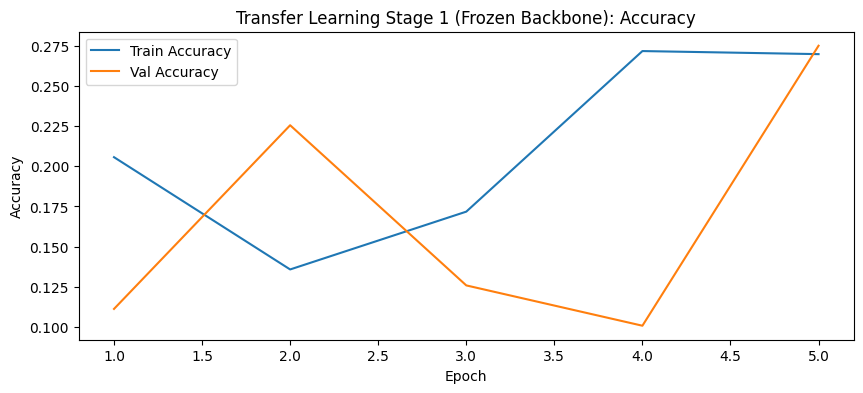

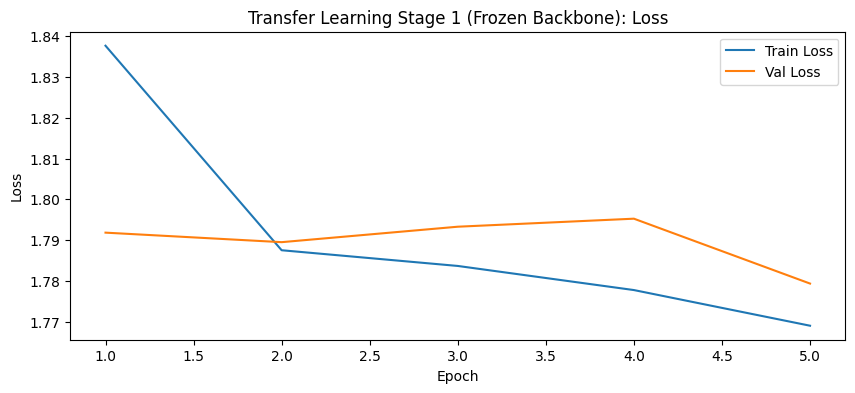

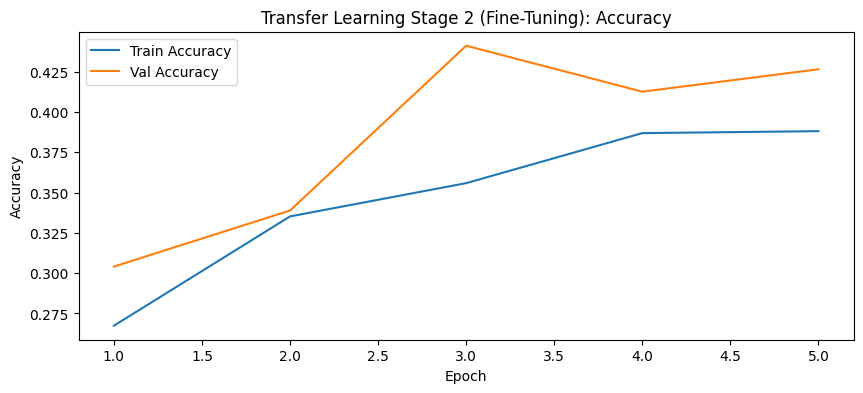

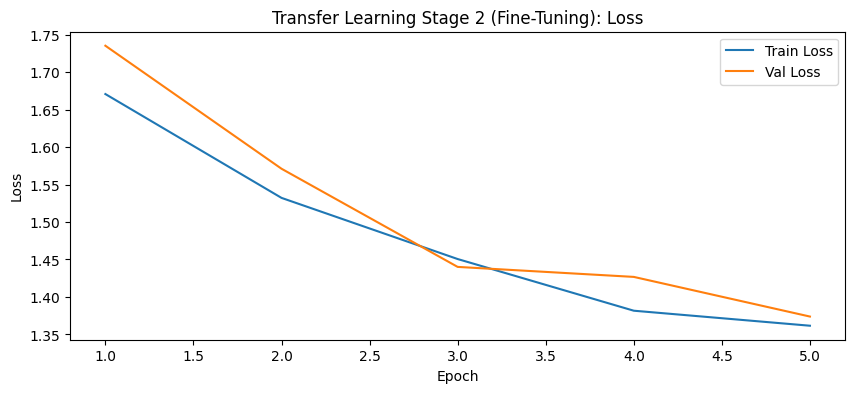

In [15]:
def plot_history(history, title_prefix="Model"):
    """
    Plot accuracy and loss curves for a single training History object.
    Used for diagnosing convergence and overfitting, and for report figures.
    """
    epochs = range(1, len(history.history["loss"]) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history.history["accuracy"], label="Train Accuracy")
    plt.plot(epochs, history.history["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}: Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history.history["loss"], label="Train Loss")
    plt.plot(epochs, history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix}: Loss")
    plt.legend()
    plt.show()

# Plot Stage 1 and Stage 2 separately (cleaner for report)
plot_history(history_tl_stage1, "Transfer Learning Stage 1 (Frozen Backbone)")
plot_history(history_tl_stage2, "Transfer Learning Stage 2 (Fine-Tuning)")

In [17]:
# Evaluate final model on validation set
val_loss, val_accuracy = tl_model.evaluate(val_data_aug)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")


45/45 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.3535 - loss: 1.4455
Validation Loss: 1.3761
Validation Accuracy: 0.4419


45/45 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step
Classification Report (Transfer Learning Model):
               precision    recall  f1-score   support

        crack       0.08      0.50      0.14        34
         dent       0.44      0.14      0.22       415
glass_shatter       0.50      0.71      0.59       237
  lamp_broken       0.34      0.53      0.41       176
      scratch       0.56      0.42      0.48       469
    tire_flat       0.55      0.64      0.59       106

     accuracy                           0.42      1437
    macro avg       0.41      0.49      0.40      1437
 weighted avg       0.48      0.42      0.41      1437


Confusion Matrix:
[[ 17   0   1   4   9   3]
 [ 71  59  61  90 113  21]
 [  7  10 168  31  15   6]
 [ 18  10  29  93  14  12]
 [ 96  48  58  54 199  14]
 [  4   6  16   4   8  68]]


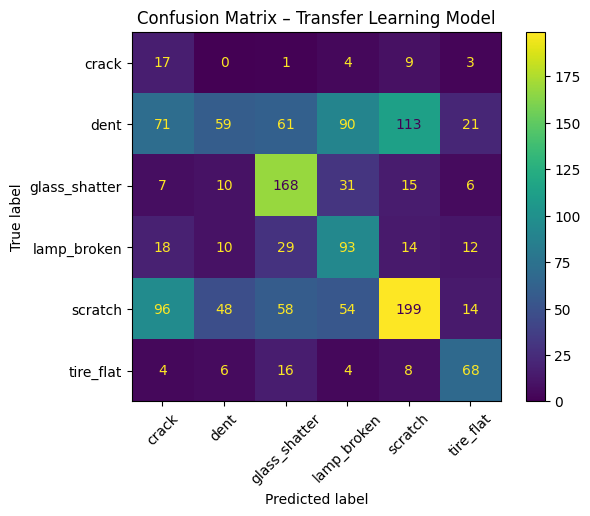

In [16]:
# Predict class probabilities on validation set
y_prob = tl_model.predict(val_data_aug)
y_pred = np.argmax(y_prob, axis=1)

# True labels from generator
y_true = val_data_aug.classes

# Class names in the correct order
class_names = list(val_data_aug.class_indices.keys())

print("Classification Report (Transfer Learning Model):")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(val_data_aug.class_indices.keys())
)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix – Transfer Learning Model")
plt.show()

In [18]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(val_data_aug.class_indices.keys())
    )
)

               precision    recall  f1-score   support

        crack       0.08      0.50      0.14        34
         dent       0.44      0.14      0.22       415
glass_shatter       0.50      0.71      0.59       237
  lamp_broken       0.34      0.53      0.41       176
      scratch       0.56      0.42      0.48       469
    tire_flat       0.55      0.64      0.59       106

     accuracy                           0.42      1437
    macro avg       0.41      0.49      0.40      1437
 weighted avg       0.48      0.42      0.41      1437



In [22]:
# ============================
# EXTRACT FINAL TRANSFER LEARNING METRICS
# ============================

acc_tl = history_tl_stage2.history["val_accuracy"][-1]
loss_tl = history_tl_stage2.history["val_loss"][-1]

print("Transfer Learning - Validation Accuracy:", acc_tl)
print("Transfer Learning - Validation Loss:", loss_tl)


Transfer Learning - Validation Accuracy: 0.4265831708908081
Transfer Learning - Validation Loss: 1.3738489151000977


In [23]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Transfer Learning (ResNet50)"],
    "Validation Accuracy": [acc_tl],
    "Validation Loss": [loss_tl]
})

results


,Model,Validation Accuracy,Validation Loss
0,Transfer Learning (ResNet50),0.426583,1.373849


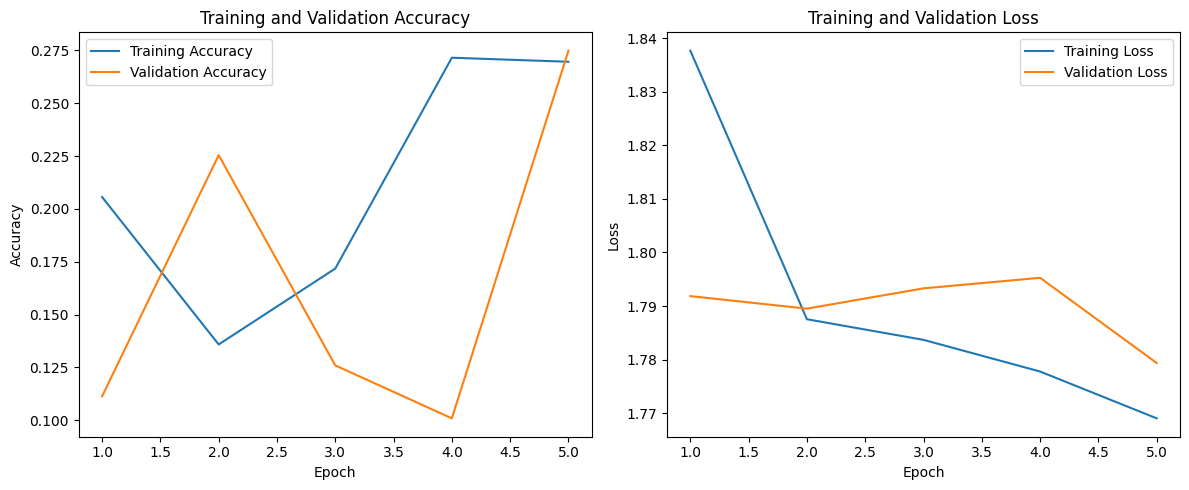

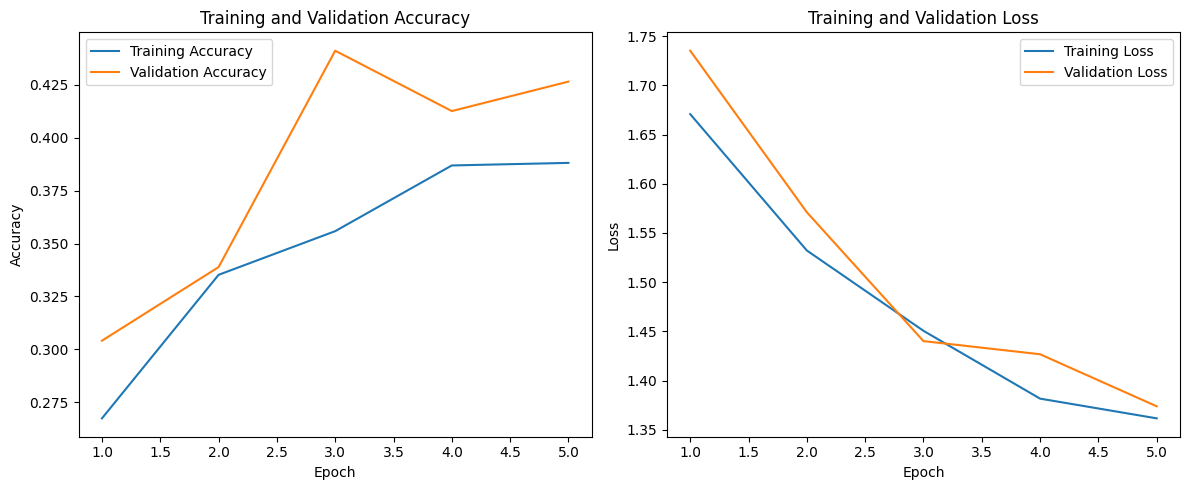

In [24]:
# Plot Stage 1 curves
plot_training_history(history_tl_stage1)

# Plot Stage 2 curves
plot_training_history(history_tl_stage2)
